In [8]:
import pandas as pd
import random

# Load the file
df = pd.read_csv("C:/Users/JOHN EDEOGHON/OneDrive/Documents/E.EdeoghonCOS102/week-4/Project 1/AB_NYC_2019.csv")

# --- 1. CLEANING THE DATA ---

# If Name, Neighborhood, or Room Type are missing, delete the whole row
# This handles the "any other categorical missing data" part
df = df.dropna(subset=['name', 'neighbourhood_group', 'neighbourhood', 'room_type'])

# If Host Name is missing, give it a simple name like "Host"
df['host_name'] = df['host_name'].fillna('Host')

# For numeric data, use the MEDIAN (the middle number)
# Median is better than Mean because it isn't affected by very high prices
df['price'] = df['price'].fillna(df['price'].median())
df['latitude'] = df['latitude'].fillna(df['latitude'].median())
df['longitude'] = df['longitude'].fillna(df['longitude'].median())
df['reviews_per_month'] = df['reviews_per_month'].fillna(df['reviews_per_month'].median())
df['minimum_nights'] = df['minimum_nights'].fillna(df['minimum_nights'].median())

# For missing ID or host_id, generate a random number
df['id'] = df['id'].fillna(random.randint(1000000, 9999999))
df['host_id'] = df['host_id'].fillna(random.randint(1000000, 9999999))

# For missing dates, pick a random date from this list
dates_list = ['2019-01-01', '2019-05-10', '2018-12-25']
df['last_review'] = df['last_review'].fillna(random.choice(dates_list))

print("Data is now clean using Median and Row Deletion!")
df.head()

Data is now clean using Median and Row Deletion!


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,2019-01-01,0.72,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


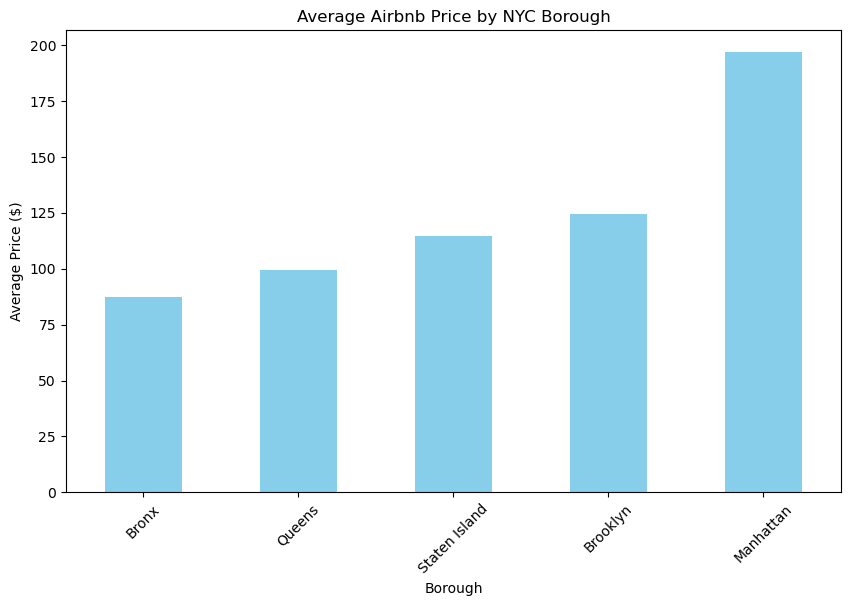

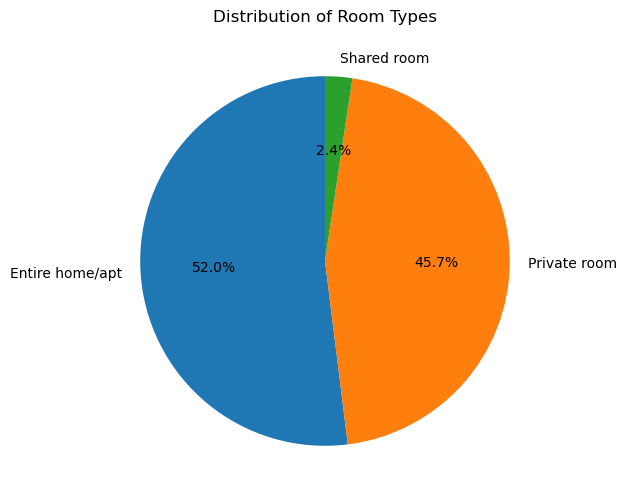

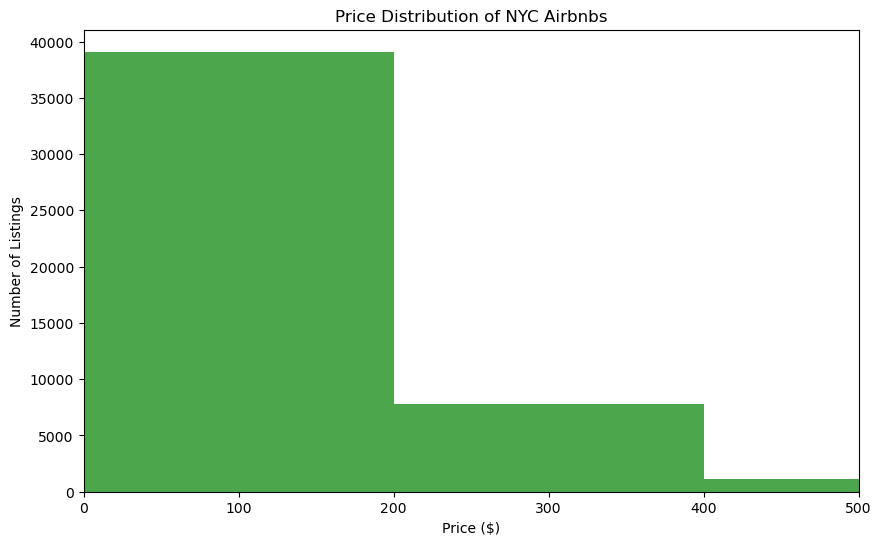

In [10]:
import matplotlib.pyplot as plt
# Example 1: Average price by neighborhood group
plt.figure(figsize=(10,6))
avg_price = df.groupby('neighbourhood_group')['price'].mean().sort_values()
avg_price.plot(kind='bar', color='skyblue')
plt.title('Average Airbnb Price by NYC Borough')
plt.xlabel('Borough')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.show()

# Example 2: Count of room types
plt.figure(figsize=(8,6))
df['room_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Room Types')
plt.ylabel('')
plt.show()

# Example 3: Price distribution (histogram)
plt.figure(figsize=(10,6))
plt.hist(df['price'], bins=50, color='green', alpha=0.7)
plt.title('Price Distribution of NYC Airbnbs')
plt.xlabel('Price ($)')
plt.ylabel('Number of Listings')
plt.xlim(0, 500)  # Zoom in on most listings
plt.show()

 First visualisation: Manhattan has the highest average prices for air bnb.
 Second visualisation: shared room have the smallest percentage
 Third visualisation: Most NYC Air bnb listings are concentrated in the lower price range (0 - 200)
